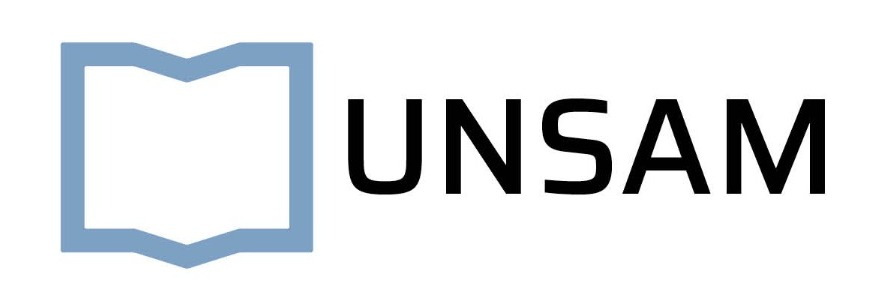

#### Análisis y Procesamiento de Señales

# TS2: Modelizando un ADC
#### Alumno: Sebastián Roca Garza



## Introducción
El siguiente trabajo tiene como objetivo principal caracterizar el comportamiento aleatorio y espectral del proceso de conversión analógica-digital (ADC). Específicamente, se busca cuantificar el impacto de dos fuentes de "ruido" independientes sobre una señal determinística: el **ruido analógico agregado** (asociado al canal o acondicionamiento previo) y el **ruido de cuantización** (intrínseco del proceso).

Para el análisis, se simulará un ADC bipolar con un rango dinámico a escala completa de $V_{FS} = 2V_F$ operando a una frecuencia de muestreo $f_S$. Al discretizar la amplitud en $2^B$ niveles, se introduce un error de cuantización cuya potencia teórica, bajo la hipótesis de cuantización uniforme, está dada por $P_q = \frac{q^2}{12}$, siendo $q$ el paso de cuantización. 

Se analizará el desempeño del sistema introduciendo un ruido Gaussiano blanco aditivo de potencia $P_n = k_n \cdot P_q$. A través del factor de escala $k_n$, se evaluarán distintos escenarios de relación señal a ruido, permitiendo discernir bajo qué condiciones el sistema se encuentra limitado por la resolución del cuantizador ($k_n \ll 1$) o por el ruido del canal analógico ($k_n \gg 1$).

# Codigo y Análisis


## Definición de Parámetros y Generación de Señales

Se define una señal senoidal de varianza unitaria. Para garantizar que la energía de la señal sea $P_s = 1\text{ W}$, la amplitud de pico debe ser $A = \sqrt{2}\text{ V}$. 

 Durante el análisis en el dominio de la frecuencia mediante la Transformada Discreta de Fourier (DFT), se selecciona una frecuencia fundamental $f_0$ que sea un múltiplo entero de la resolución espectral $\Delta f = \frac{f_S}{N}$ con el fin de evitar el fenómeno de dispersión espectral (*spectral leakage*)

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fs = 1000
N = 1000

vmax = np.sqrt(2)
dc = 0
f= 1
ph = 0
mu = 0

def mi_funcion_sen(vmax=vmax, dc=dc, f=f, ph=ph, nn=N, fs=fs):

    n = np.arange(0, nn, 1)
    tt = n / fs
    xx = vmax * np.sin(2 * np.pi * f * tt + ph) + dc

    return tt, xx

tt, xx = mi_funcion_sen(
    vmax=vmax,
    dc=dc,
    f=f,
    ph=ph,
    nn=N,
    fs=fs
) 

delta_f = fs / N # Resolucion espectral
bins = np.arange(0, N // 2) * delta_f # hasta nyquist

B = 4 # Bits
vf = 2 # Vf, amplitud de pico 
q = 2*vf/(2**B) # 2Vf = Vfs, full scale range
                # q = paso de cuantizacion

Pq = q**2 / 12 # Potencia del ruido de cuantizacion teorica



#CASO K=1
k = 1

pn = k * Pq # Pot analogica

desv_est = np.sqrt(pn)

n = np.random.normal(mu, desv_est, N)# muestras ruido analogico

senal_final = xx + n # señal mas ruido analogico



xx_q = np.round(senal_final / q) * q # salida cuantizada del adc
nq = xx_q - senal_final

### Análisis en el Dominio del Tiempo

En la siguiente figura se superponen la señal analógica contaminada ($s_R = s + n$) y la salida discreta del cuantizador ($s_Q$). 

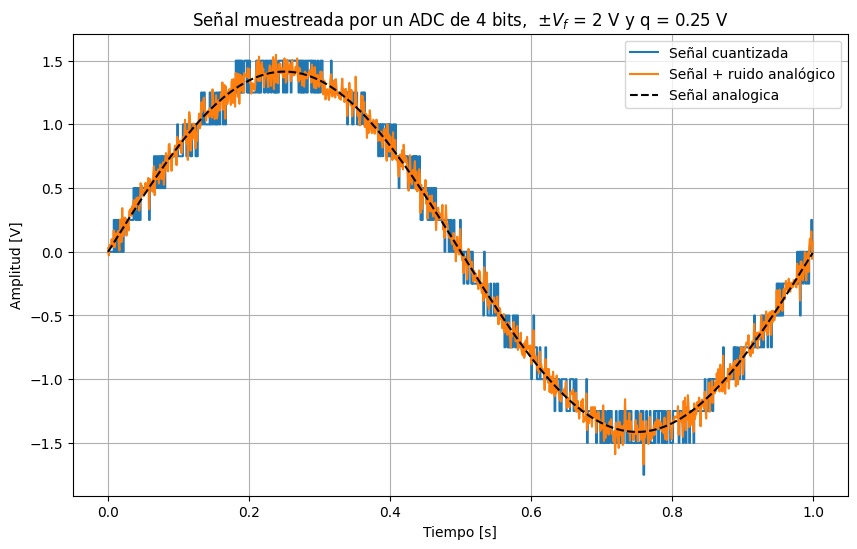

In [28]:
plt.figure(figsize=(10,6))

plt.step(tt, xx_q, where='post', label='Señal cuantizada')
plt.plot(tt, senal_final, label='Señal + ruido analógico')
plt.plot(tt,xx,color ='black', linestyle = '--', label ='Señal analogica')

plt.title('Señal muestreada por un ADC de ' + str(B) + ' bits,  $\pm V_f$ = ' + str(vf) + ' V y q = ' + str(round(q,4)) + ' V')

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend()
plt.show()

En la configuración de $B = 4$ bits y $k_n = 1$, el conversor opera con una resolución baja, generando escalones de voltaje relativamente grandes ($q = 0.25\text{ V}$). Al establecer que el ruido analógico externo tenga la misma potencia que el error de cuantización ($P_n = P_q$), las fluctuaciones aleatorias presentes en la entrada (el ruido térmico de los componentes o cables) alcanzan amplitudes similares al tamaño de un escalón del conversor.Como consecuencia, un simple pico de ruido analógico es suficiente para cruzar el umbral de decisión del ADC, provocando saltos erráticos y falsos positivos en el nivel lógico de salida. Esto demuestra que, en este escenario, la interferencia del entorno analógico se solapa directamente con la baja precisión del conversor, degradando de forma grave la medición.

### Análisis Espectral (Densidad Espectral de Potencia)

El análisis en el dominio de la frecuencia es fundamental para observar el piso de ruido introducido por ambas fuentes de error. Se calcula el módulo al cuadrado de la FFT normalizada por la longitud del registro $N$, escalada logarítmicamente a decibelios (dB).

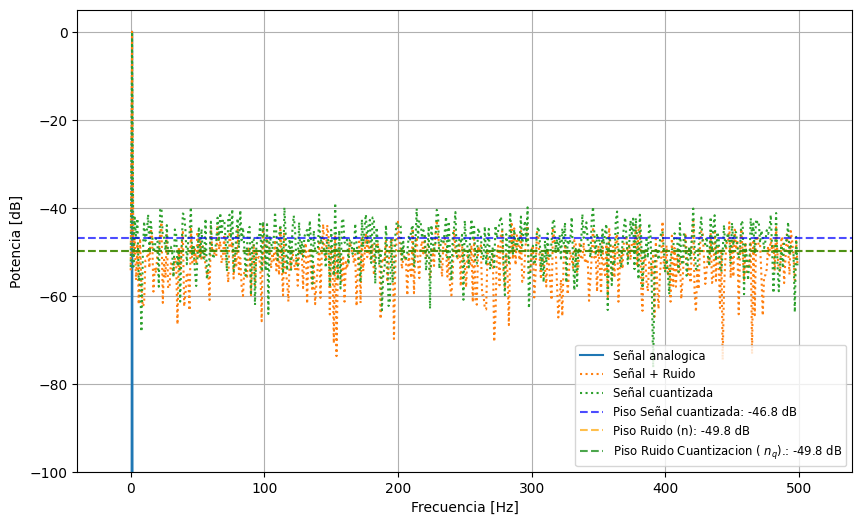

In [29]:
# Cálculo de las FFT (de las señales, no de los ruidos sueltos)
xx_k = (1/N) * np.fft.fft(xx)                # s (analog)
s_r_k = (1/N) * np.fft.fft(senal_final)      # s_R = s + n (ADC in)
xx_q_k = (1/N) * np.fft.fft(xx_q)            # s_Q = Q(s_R) (ADC out)

# Cálculo de las potencias usando el módulo | | al cuadrado
pot_xx = 2 * (np.abs(xx_k[0:(N//2)])**2)
pot_s_r = 2 * (np.abs(s_r_k[0:(N//2)])**2)
pot_xx_q = 2 * (np.abs(xx_q_k[0:(N//2)])**2)

# Paso a dB
pot_xx_db = 10 * np.log10(pot_xx)
pot_s_r_db = 10 * np.log10(pot_s_r)
pot_xx_q_db = 10 * np.log10(pot_xx_q)

# Cálculo pisos de ruido
        
piso_ruido_teorico_db = 10 * np.log10(2 * pn / N) # Piso ruido analógico (n)

piso_nq_teorico_db = 10 * np.log10(2 * Pq / N) # Piso ruido de cuantización (nq)

piso_total_teorico_db = 10 * np.log10(2 * (pn + Pq) / N) # Piso total (señal final cuantizada)
# -----------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(bins, pot_xx_db, label='Señal analogica')
plt.plot(bins, pot_s_r_db, ':', label='Señal + Ruido')
plt.plot(bins, pot_xx_q_db, ':', label='Señal cuantizada')

# Pisos 
plt.axhline(piso_total_teorico_db, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Piso Señal cuantizada: {round(piso_total_teorico_db,1)} dB')
plt.axhline(piso_ruido_teorico_db, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Piso Ruido (n): {round(piso_ruido_teorico_db,1)} dB')
plt.axhline(piso_nq_teorico_db, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Piso Ruido Cuantizacion ( $n_q$).: {round(piso_nq_teorico_db,1)} dB')
# ---------------------------------------------------------

plt.xlim(-40, 540)
plt.ylim(-100, 5)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid()
# Achicamos un poco la letra de la leyenda para que entren todos
plt.legend(loc='lower right', fontsize='small') 
plt.show()

A partir del gráfico obtenido, se observa como debido a que la simulación se configuró con un factor $k_n = 1$, la potencia del ruido analógico agregado ($P_n$) resulta exactamente igual a la potencia del ruido de cuantización intrínseco del ADC ($P_q$). Esto se evidencia claramente en el espectro, donde los pisos teóricos de ambos ruidos individuales (líneas amarilla y verde) se superponen en el valor de -49.8 dB. La señal digitalizada a la salida del ADC arrastra la suma de ambas perturbaciones. Como el ruido térmico analógico y el error de cuantización son variables aleatorias independientes e incorreladas, sus potencias se suman de forma lineal ($P_{total} = P_n + P_q$). Al cumplirse que $P_n = P_q$, la potencia de ruido total es el doble de la de una sola fuente. En términos de decibeles, duplicar la potencia equivale a un incremento de $10 \log_{10}(2) \approx 3$. El gráfico confirma empíricamente este fenómeno teórico, ya que el piso de ruido total de la señal final cuantizada (línea azul) se establece en -46.8 dB, elevándose exactamente 3 dB por encima de los pisos individuales.

## Análisis Estadístico y Propiedades de Incorrelación


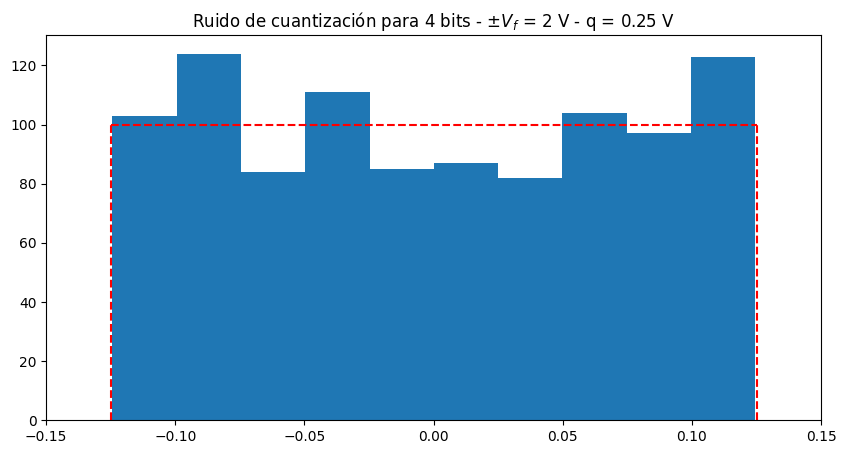

In [34]:

# Histograma
plt.figure(figsize=(10, 5))

plt.hist(nq, bins=10, density=False, label='Error de cuantización')

#  techo y paredes de la caja roja
q_medios = q / 2
altura_ideal = N / 10 # N es tu cantidad total de muestras

# Línea horizontal 
plt.plot([-q_medios, q_medios], [altura_ideal, altura_ideal], 'r--')
# Líneas verticales 
plt.vlines([-q_medios, q_medios], ymin=0, ymax=altura_ideal, colors='r', linestyles='dashed')

plt.title('Ruido de cuantización para ' + str(B) + ' bits - $\pm V_f$ = ' + str(vf) + ' V - q = ' + str(round(q,3)) + ' V')
plt.xlim(-q_medios * 1.2, q_medios * 1.2) 

plt.show()


El histograma obtenido evalúa el comportamiento estadístico del error de cuantización ($n_q$) introducido por el proceso de digitalización del ADC. Para la configuración simulada de 4 bits y un rango de tensión de $\pm 2\text{ V}$, el escalón resultante es $q = 0.25\text{ V}$. El gráfico confirma este principio: la totalidad de las muestras del error se encuentran estrictamente confinadas dentro del intervalo $[-q/2, q/2]$. Asimismo, la teoría estadística de procesamiento de señales establece que, cuando la señal de entrada atraviesa múltiples niveles de cuantización, el error se comporta como una variable aleatoria de distribución uniforme, lo que implica que cualquier valor dentro del intervalo permitido tiene la misma probabilidad de ocurrir. El recuadro rojo punteado en el gráfico representa esta distribución ideal esperada. Al contar con una cantidad finita de muestras distribuidas en 10 intervalos (bins), las alturas de las barras fluctúan de manera aleatoria pero contenida alrededor del valor teórico constante. Estas variaciones confirman que el error de la simulación se ajusta exitosamente al modelo teórico de un ruido blanco de distribución uniforme.

## Comparación de Escenarios: Variación de Resolución y Ruido 

Para comparar el impacto combinado de la resolución del ADC ($B \in \{4, 8, 16\}$ bits) y la potencia del ruido analógico ($k_n \in \{0.1, 1, 10\}$),
se graficarán los espectros de potencia resultantes para ver cómo el piso de ruido total del sistema se ve dominado ya sea por el canal analógico o por la cuantización.

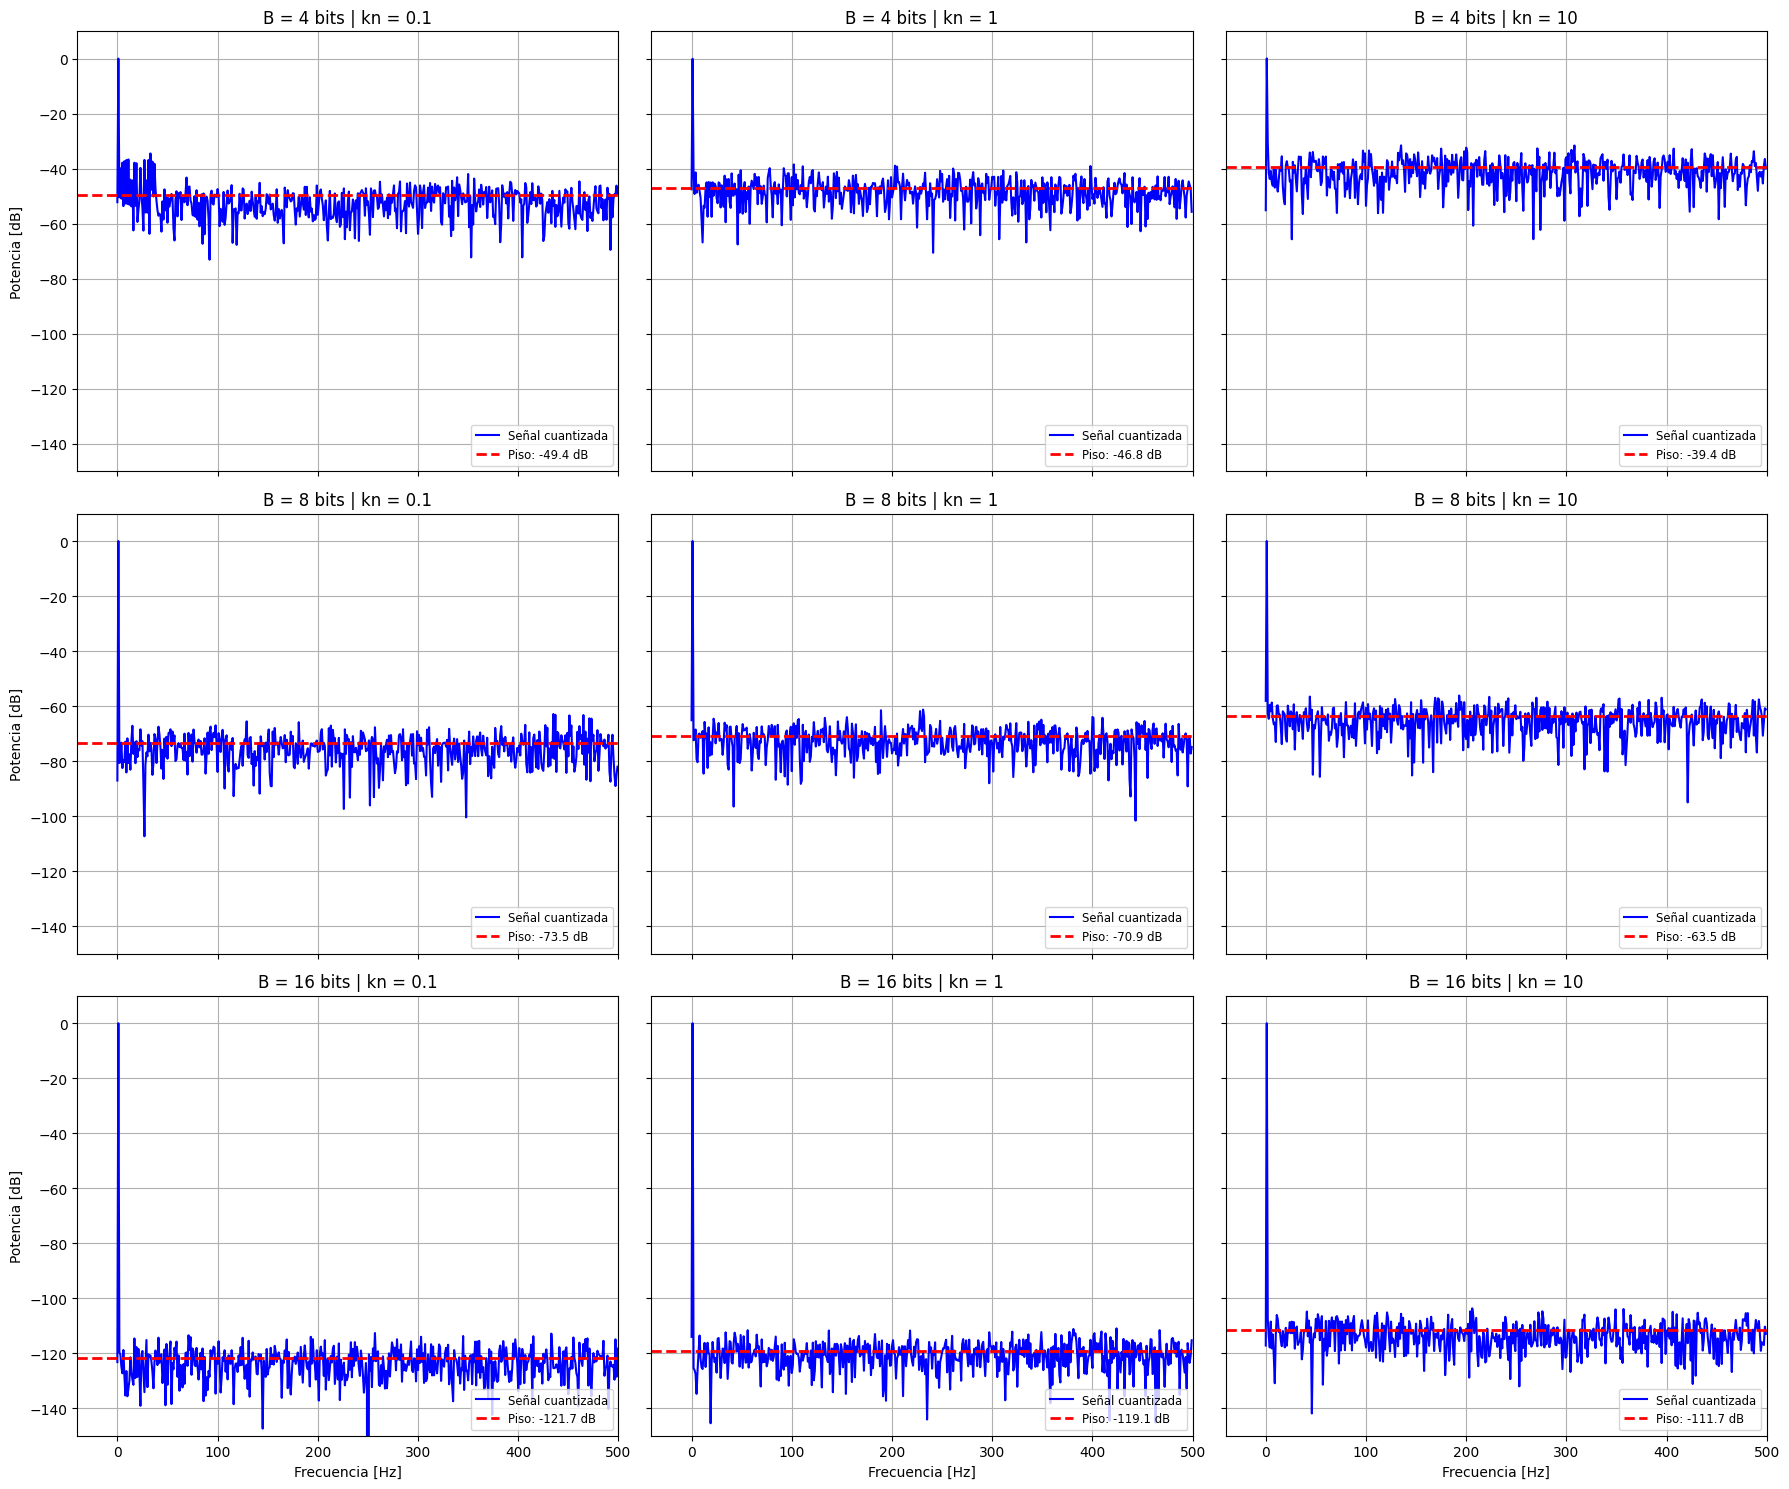

In [31]:

bits_array = [4, 8, 16]
k_array = [0.1, 1, 10]

fig, axs = plt.subplots(3, 3, figsize=(18, 15), sharex=True, sharey=True)

for i, B_test in enumerate(bits_array):
    for j, k_test in enumerate(k_array):
        
        # Recalculamos q y Pq para el B actual
        q_test = 2 * vf / (2**B_test)
        Pq_test = (q_test**2) / 12
        
        # Recalculamos el ruido para el k actual
        pn_test = k_test * Pq_test
        ruido_test = np.random.normal(0, np.sqrt(pn_test), N)
        senal_final_test = xx + ruido_test
        
        # Cuantizacion
        xx_q_test = np.round(senal_final_test / q_test) * q_test
        nq_test = xx_q_test - senal_final_test
        
        # Calculo FFT
        xx_q_k_test = (1/N) * np.fft.fft(xx_q_test)
        pot_xx_q_test = 2 * (np.abs(xx_q_k_test[0:(N//2)])**2)
        pot_xx_q_db_test = 10 * np.log10(pot_xx_q_test)
        
        # Calculo del piso teórico para este B y kn específico 
        piso_test_db = 10 * np.log10(2 * (pn_test + Pq_test) / N)
        
        # grilla 
        ax = axs[i, j]
        ax.plot(bins, pot_xx_q_db_test, label='Señal cuantizada', color='blue')
        
        #  línea del piso 
        ax.axhline(piso_test_db, color='red', linestyle='--', linewidth=2, label=f'Piso: {round(piso_test_db, 1)} dB')
        
        ax.set_title(f'B = {B_test} bits | kn = {k_test}')
        ax.set_xlim(-40, 500)
        ax.set_ylim(-150, 10)
        ax.grid(True)
        ax.legend(loc='lower right', fontsize='small') # Mostramos la leyenda con el valor del piso
        
        if i == 2:
            ax.set_xlabel('Frecuencia [Hz]')
        if j == 0:
            ax.set_ylabel('Potencia [dB]')

plt.tight_layout()
plt.show()

**Análisis de Espectros:**

Al observar los gtaficos queda en evidencia que dos patrones claros:

* Efecto de la Resolución del ADC (Análisis por filas): Al mantener constante el factor de ruido $k_n$ y desplazar la observación verticalmente, se evidencia el impacto de la cantidad de bits sobre el piso de ruido total. Al pasar de 4 bits a 8 bits, el piso teórico desciende aproximadamente 24 dB (pasando de -49.4 dB a -73.5 dB para el caso de menor interferencia). Al dar el salto a 16 bits, el piso experimenta una caída adicional de 48 dB, alcanzando los -121.7 dB. Este comportamiento corrobora la regla teórica de diseño que establece que cada bit de resolución adicional mejora la dinámica del sistema en aproximadamente 6 dB.
  
* Efecto de la Interferencia Analógica (Análisis por columnas): Al observar las columnas de izquierda a derecha para una resolución fija, se verifica el impacto del entorno. A medida que el multiplicador $k_n$ aumenta, incrementando la potencia del ruido térmico ($P_n$) respecto al ruido de cuantización intrínseco ($P_q$), el piso total del espectro se eleva. En la fila de 8 bits, el piso sube desde -73.5 dB en el entorno más limpio, hasta -63.5 dB en el caso dominado por el ruido analógico ($k_n = 10$).



# Conclusión


A partir del análisis de la matriz de simulaciones (variando la resolución del conversor $B$ y el factor de escala del ruido analógico $k_n$), se observa que el desempeño global del sistema de adquisición de datos está determinado por la interacción directa entre el ruido de cuantización del ADC y las perturbaciones del entorno analógico. En primer lugar, los histogramas del error de cuantización corroboran el comportamiento teórico esperado, ajustándose a una distribución uniforme acotada dentro del intervalo $[-q/2, q/2]$.En segundo lugar, el análisis espectral y la evaluación de los pisos de potencia demuestran que incrementar la resolución en bits ($B$) reduce significativamente el piso de ruido total del sistema. Incluso en escenarios con fuerte presencia de interferencia analógica ($k_n = 10$), la utilización de mayores resoluciones (como 16 bits) disminuye drásticamente el error global de la señal digitalizada frente bajas resoluciones (4 u 8 bits). No obstante, la elección óptima del conversor debe evaluar un balance de diseño. Por lo tanto, dimensionar correctamente el arrelgo del ADC en función de la naturaleza de la señal y el piso de ruido del canal resulta fundamental para evitar tanto la pérdida de información útil como la sobreespecificación innecesaria del sistema.